## Data Validation

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv('army_personnel_data.csv')
print(df.shape)          # (500, 48) — rows, columns
print(df.head())         # first 5 rows

(500, 48)
  SOLDIER_ID LAST_NAME FIRST_NAME GENDER  AGE HOME_STATE RANK PAY_GRADE  \
0    US-0001  Anderson      James      M   40         CO  MSG        E8   
1    US-0002    Harris    DeShawn      M   30         PA  CPL        E4   
2    US-0003     Young    DeShawn      M   22         PA  SSG        E6   
3    US-0004  Thompson      Tanya      F   31         NC  SGT        E5   
4    US-0005      King      Tyler      M   22         AL  SGM        E9   

  MOS_CODE                 MOS_TITLE  ... RANGER_TAB VEHICLE_QUALIFIED  \
0      13F   Fire Support Specialist  ...         NO               NaN   
1      35F      Intelligence Analyst  ...        YES               NaN   
2      88M  Motor Transport Operator  ...         NO              LMTV   
3      88M  Motor Transport Operator  ...         NO              FMTV   
4      25B             IT Specialist  ...         NO               NaN   

                  AWARD_1                  AWARD_2        EVAL_RATING  \
0      Combat Medic B

In [2]:
print(df.dtypes)          # data type per column
print(df.info())          # nulls + dtypes together
print(df.columns.tolist()) # all column names

SOLDIER_ID                object
LAST_NAME                 object
FIRST_NAME                object
GENDER                    object
AGE                        int64
HOME_STATE                object
RANK                      object
PAY_GRADE                 object
MOS_CODE                  object
MOS_TITLE                 object
MOS_BRANCH                object
BRIGADE                   object
BATTALION                 object
COMPANY                   object
PLATOON                   object
ENLISTMENT_DATE           object
YEARS_OF_SERVICE         float64
STATUS                    object
DEPLOYMENT                object
THEATER                   object
DEPLOY_MONTHS              int64
COMBAT_TOURS               int64
BASE_PAY_USD               int64
BAH_USD                    int64
BAS_USD                    int64
TOTAL_MONTHLY_PAY_USD      int64
ACFT_TOTAL_SCORE           int64
ACFT_STATUS               object
RUN_TIME_MIN             float64
PUSHUPS_COUNT              int64
SITUPS_COU

In [3]:
print(df.describe())                    # numeric cols only
print(df.describe(include='object'))    # text cols

              AGE  YEARS_OF_SERVICE  DEPLOY_MONTHS  COMBAT_TOURS  \
count  500.000000        500.000000     500.000000    500.000000   
mean    31.282000         10.706000       4.466000      0.534000   
std      7.953426          5.336114       5.280209      0.765517   
min     18.000000          1.500000       0.000000      0.000000   
25%     25.000000          5.900000       0.000000      0.000000   
50%     31.000000         10.900000       2.000000      0.000000   
75%     38.000000         15.525000       9.000000      1.000000   
max     45.000000         19.300000      15.000000      2.000000   

       BASE_PAY_USD      BAH_USD     BAS_USD  TOTAL_MONTHLY_PAY_USD  \
count    500.000000   500.000000  500.000000             500.000000   
mean    4038.004000   748.298000  364.280000            5150.582000   
std     1616.330377   807.143776   75.392903            1764.460914   
min     1917.000000     0.000000  266.000000            2339.000000   
25%     2504.000000     0.000000

## Find Missing values

In [4]:
missing = df.isnull().sum()
missing_pct = (df.isnull().sum() / len(df) * 100).round(2)
missing_df = pd.DataFrame({'count': missing, 'pct': missing_pct})
print(missing_df[missing_df['count'] > 0])

                    count   pct
SECURITY_CLEARANCE    126  25.2
VEHICLE_QUALIFIED     193  38.6
AWARD_1               125  25.0
AWARD_2               315  63.0


## Remove duplicates

In [5]:
print(f'Before: {len(df)} rows')
df = df.drop_duplicates(subset=['SOLDIER_ID'])
print(f'After:  {len(df)} rows')

Before: 500 rows
After:  500 rows


## Find MIssing Values

In [6]:
# Numeric — fill with median
df['AGE'] = df['AGE'].fillna(df['AGE'].median())

# Categorical — fill with mode (most common)
df['SECURITY_CLEARANCE'] = df['SECURITY_CLEARANCE'].fillna(df['SECURITY_CLEARANCE'].mode()[0])

# Check the fix worked — print null counts before and after
print("=== MISSING VALUES AFTER FILL ===")
print(df[['AGE', 'SECURITY_CLEARANCE']].isnull().sum())

print("\n=== AGE STATS ===")
print(f"Median Age: {df['AGE'].median()}")
print(f"Min: {df['AGE'].min()}  |  Max: {df['AGE'].max()}")

print("\n=== SECURITY CLEARANCE VALUES ===")
print(df['SECURITY_CLEARANCE'].value_counts())

print("\n=== SAMPLE — first 5 rows ===")
print(df[['SOLDIER_ID', 'AGE', 'SECURITY_CLEARANCE']].head())

=== MISSING VALUES AFTER FILL ===
AGE                   0
SECURITY_CLEARANCE    0
dtype: int64

=== AGE STATS ===
Median Age: 31.0
Min: 18  |  Max: 45

=== SECURITY CLEARANCE VALUES ===
SECURITY_CLEARANCE
Top Secret    261
Secret        129
TS/SCI        110
Name: count, dtype: int64

=== SAMPLE — first 5 rows ===
  SOLDIER_ID  AGE SECURITY_CLEARANCE
0    US-0001   40             TS/SCI
1    US-0002   30         Top Secret
2    US-0003   22             TS/SCI
3    US-0004   31         Top Secret
4    US-0005   22             TS/SCI


## Add RANK_TIER column

In [7]:
officers = ['2LT','1LT','CPT','MAJ','LTC','COL']
ncos = ['SGT','SSG','SFC','MSG','1SG','SGM']

df['RANK_TIER'] = df['RANK'].apply(
    lambda x: 'Officer' if x in officers
              else ('NCO' if x in ncos else 'Enlisted'))

print(df['RANK_TIER'].value_counts())

RANK_TIER
Officer     185
NCO         184
Enlisted    131
Name: count, dtype: int64


## Add FITNESS_GRADE and ANNUAL_PAY

In [8]:
def grade(score):
    if score >= 540: return 'A'
    elif score >= 480: return 'B'
    elif score >= 420: return 'C'
    elif score >= 360: return 'D'
    else: return 'F'

df['FITNESS_GRADE'] = df['ACFT_TOTAL_SCORE'].apply(grade)
df['ANNUAL_PAY_USD'] = df['TOTAL_MONTHLY_PAY_USD'] * 12

# ── PRINT RESULTS ──────────────────────────────
print("=== FITNESS GRADE DISTRIBUTION ===")
print(df['FITNESS_GRADE'].value_counts().sort_index())

print("\n=== ANNUAL PAY STATS ===")
print(f"Min:    ${df['ANNUAL_PAY_USD'].min():,.0f}")
print(f"Max:    ${df['ANNUAL_PAY_USD'].max():,.0f}")
print(f"Mean:   ${df['ANNUAL_PAY_USD'].mean():,.0f}")
print(f"Median: ${df['ANNUAL_PAY_USD'].median():,.0f}")

print("\n=== SAMPLE — 5 ROWS ===")
print(df[['SOLDIER_ID','RANK','ACFT_TOTAL_SCORE',
          'FITNESS_GRADE','TOTAL_MONTHLY_PAY_USD',
          'ANNUAL_PAY_USD']].head())

=== FITNESS GRADE DISTRIBUTION ===
FITNESS_GRADE
A     97
B     91
C    104
D    102
F    106
Name: count, dtype: int64

=== ANNUAL PAY STATS ===
Min:    $28,068
Max:    $118,248
Mean:   $61,807
Median: $61,890

=== SAMPLE — 5 ROWS ===
  SOLDIER_ID RANK  ACFT_TOTAL_SCORE FITNESS_GRADE  TOTAL_MONTHLY_PAY_USD  \
0    US-0001  MSG               548             A                   5161   
1    US-0002  CPL               475             C                   2926   
2    US-0003  SSG               495             B                   3402   
3    US-0004  SGT               595             A                   5345   
4    US-0005  SGM               347             F                   5895   

   ANNUAL_PAY_USD  
0           61932  
1           35112  
2           40824  
3           64140  
4           70740  


## Seniority band and ETS risk

In [9]:
df['SENIORITY_BAND'] = pd.cut(
    df['YEARS_OF_SERVICE'],
    bins=[0,2,6,12,50],
    labels=['Junior','Mid','Senior','Veteran'])

df['ETS_RISK'] = df['DAYS_UNTIL_ETS'].apply(
    lambda x: 'Separated' if x<0
              else ('Imminent' if x<=90
              else ('Soon' if x<=180 else 'Retained')))

# ── PRINT RESULTS ──────────────────────────────
print("=== SENIORITY BAND DISTRIBUTION ===")
print(df['SENIORITY_BAND'].value_counts().sort_index())

print("\n=== ETS RISK DISTRIBUTION ===")
print(df['ETS_RISK'].value_counts())

print("\n=== RETENTION RISK % ===")
total = len(df)
for risk in ['Imminent','Soon','Separated','Retained']:
    count = (df['ETS_RISK'] == risk).sum()
    print(f"{risk:12}: {count:>4} soldiers  ({count/total*100:.1f}%)")

print("\n=== SAMPLE — 5 ROWS ===")
print(df[['SOLDIER_ID','RANK','YEARS_OF_SERVICE',
          'SENIORITY_BAND','DAYS_UNTIL_ETS',
          'ETS_RISK']].head())

=== SENIORITY BAND DISTRIBUTION ===
SENIORITY_BAND
Junior      16
Mid        116
Senior     146
Veteran    222
Name: count, dtype: int64

=== ETS RISK DISTRIBUTION ===
ETS_RISK
Retained     346
Separated    121
Imminent      19
Soon          14
Name: count, dtype: int64

=== RETENTION RISK % ===
Imminent    :   19 soldiers  (3.8%)
Soon        :   14 soldiers  (2.8%)
Separated   :  121 soldiers  (24.2%)
Retained    :  346 soldiers  (69.2%)

=== SAMPLE — 5 ROWS ===
  SOLDIER_ID RANK  YEARS_OF_SERVICE SENIORITY_BAND  DAYS_UNTIL_ETS  ETS_RISK
0    US-0001  MSG              17.5        Veteran             878  Retained
1    US-0002  CPL               3.0            Mid             358  Retained
2    US-0003  SSG              10.9         Senior            1254  Retained
3    US-0004  SGT              17.0        Veteran            1550  Retained
4    US-0005  SGM              16.0        Veteran            1233  Retained


## Distribution of ACFT scores

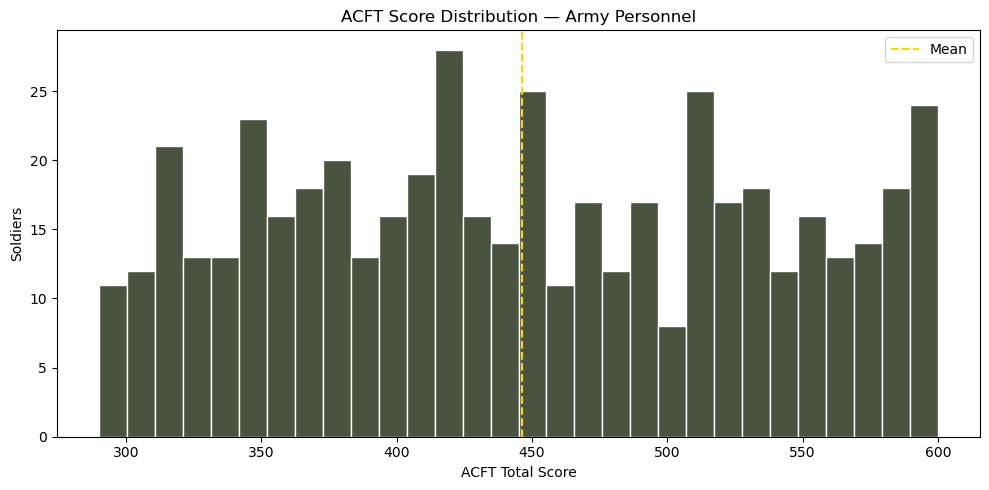

In [10]:
plt.figure(figsize=(10,5))
plt.hist(df['ACFT_TOTAL_SCORE'], bins=30,
         color='#4A5240', edgecolor='white')
plt.axvline(df['ACFT_TOTAL_SCORE'].mean(), color='gold',
            linestyle='--', label='Mean')
plt.title('ACFT Score Distribution — Army Personnel')
plt.xlabel('ACFT Total Score'); plt.ylabel('Soldiers')
plt.legend(); plt.tight_layout(); plt.savefig('acft_dist.png', dpi=150)
plt.show()

## Count plot - Rank Distribution

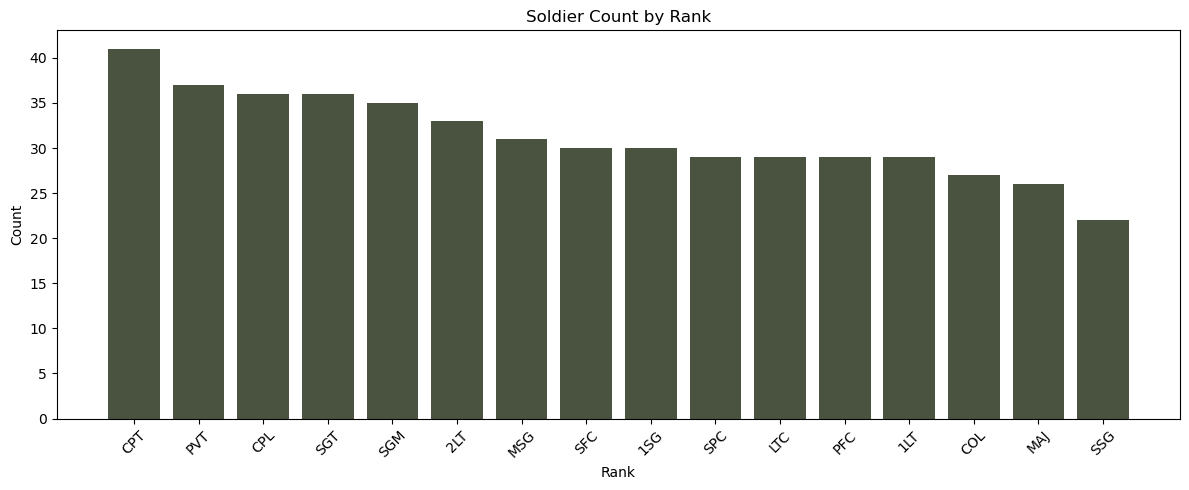

In [11]:
plt.figure(figsize=(12,5))
rank_counts = df['RANK'].value_counts()
plt.bar(rank_counts.index, rank_counts.values, color='#4A5240')
plt.title('Soldier Count by Rank'); plt.xlabel('Rank')
plt.ylabel('Count'); plt.xticks(rotation=45)
plt.tight_layout(); plt.savefig('rank_dist.png', dpi=150)
plt.show()

## Pie chart - ACFT Pass/Fail

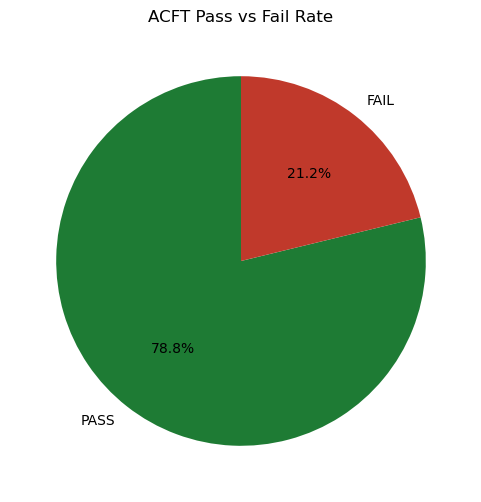

In [12]:
counts = df['ACFT_STATUS'].value_counts()
colors = ['#1E7B34','#C0392B']
plt.figure(figsize=(6,6))
plt.pie(counts, labels=counts.index, colors=colors,
        autopct='%1.1f%%', startangle=90)
plt.title('ACFT Pass vs Fail Rate')
plt.savefig('acft_pie.png', dpi=150); plt.show()

## Box plot - ACFT score by rank tier

RANK_TIER
Officer     185
NCO         184
Enlisted    131
Name: count, dtype: int64


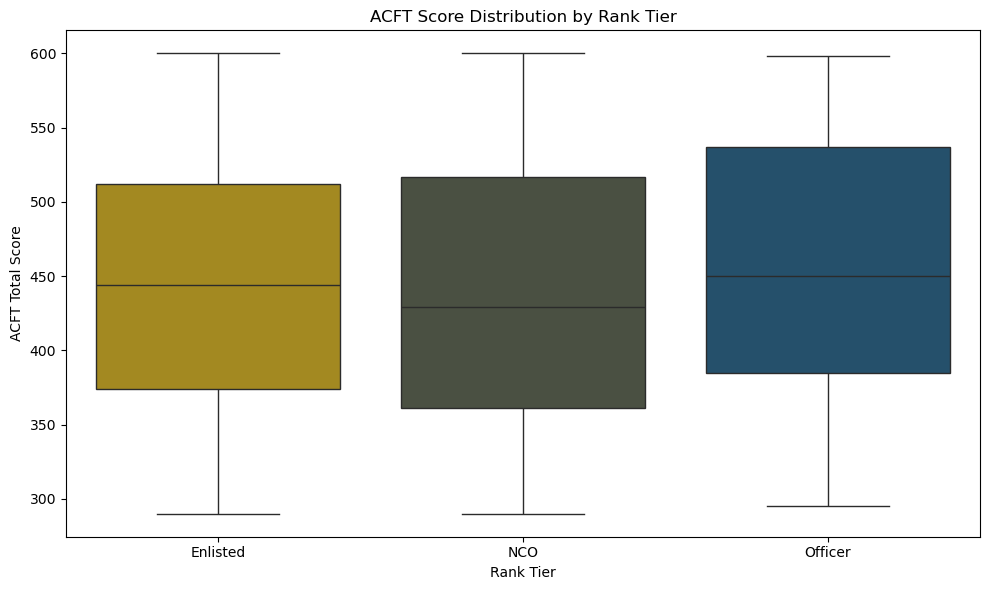

In [13]:
# Step 1 — Create RANK_TIER if it doesn't exist
officers  = ['2LT','1LT','CPT','MAJ','LTC','COL']
ncos      = ['SGT','SSG','SFC','MSG','1SG','SGM']

df['RANK_TIER'] = df['RANK'].apply(
    lambda x: 'Officer' if x in officers
              else ('NCO' if x in ncos else 'Enlisted'))

# Step 2 — Verify it was created
print(df['RANK_TIER'].value_counts())

# Step 3 — Now plot
plt.figure(figsize=(10,6))
order = ['Enlisted','NCO','Officer']

sns.boxplot(data=df, x='RANK_TIER', y='ACFT_TOTAL_SCORE',
            order=order,
            hue='RANK_TIER',
            palette=['#4A5240','#B8960C','#1A5276'],
            legend=False)

plt.title('ACFT Score Distribution by Rank Tier')
plt.xlabel('Rank Tier')
plt.ylabel('ACFT Total Score')
plt.tight_layout()
plt.savefig('acft_boxplot.png', dpi=150)
plt.show()

# By chart - AVG pay by Brigade

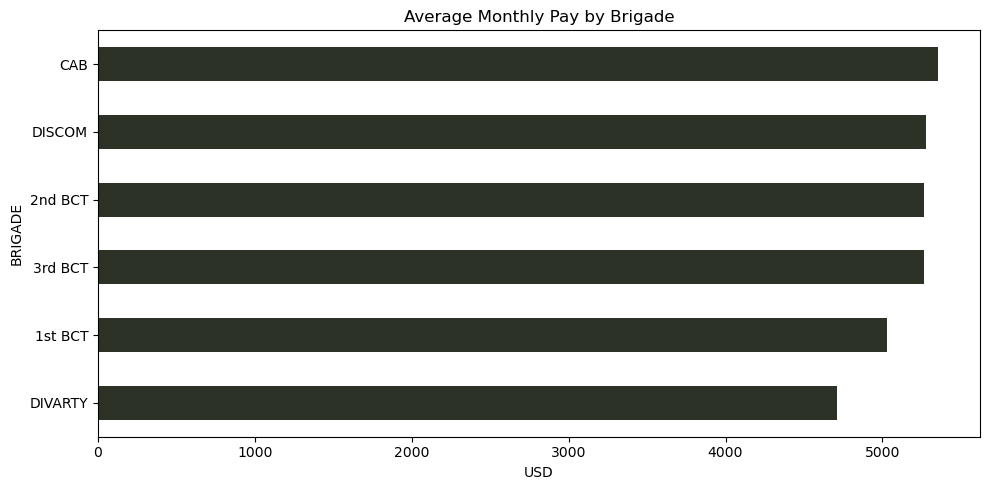

In [14]:
pay_by_brig = df.groupby('BRIGADE')['TOTAL_MONTHLY_PAY_USD'].mean().sort_values()
plt.figure(figsize=(10,5))
pay_by_brig.plot(kind='barh', color='#2C3326')
plt.title('Average Monthly Pay by Brigade')
plt.xlabel('USD'); plt.tight_layout()
plt.savefig('pay_brigade.png', dpi=150); plt.show()

## Scatter - Years of service vs ACFT

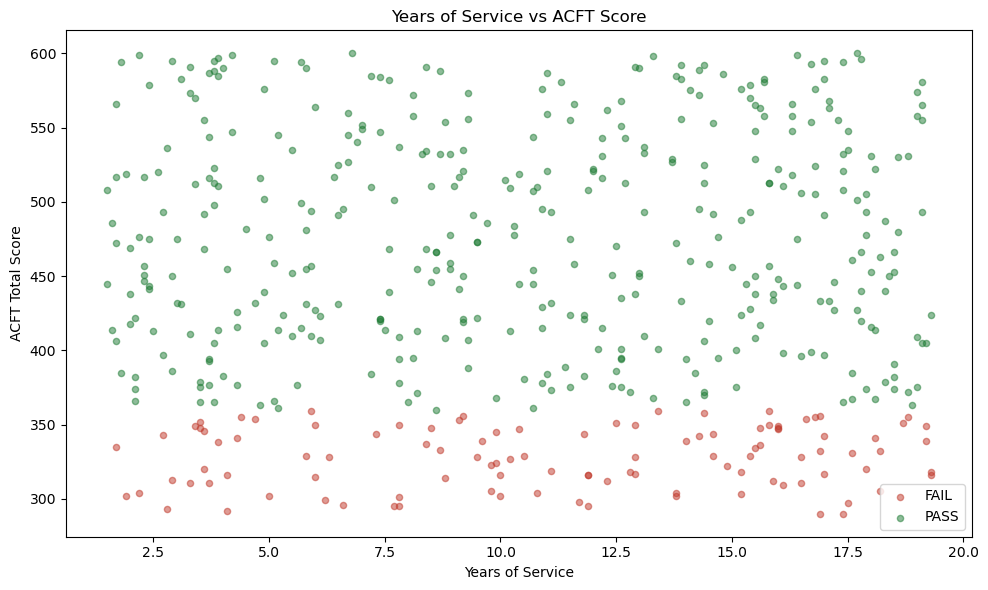

In [15]:
plt.figure(figsize=(10,6))
colors = {'PASS':'#1E7B34','FAIL':'#C0392B'}
for status, grp in df.groupby('ACFT_STATUS'):
    plt.scatter(grp['YEARS_OF_SERVICE'], grp['ACFT_TOTAL_SCORE'],
                c=colors[status], label=status, alpha=0.5, s=20)
plt.title('Years of Service vs ACFT Score')
plt.xlabel('Years of Service'); plt.ylabel('ACFT Total Score')
plt.legend(); plt.tight_layout()
plt.savefig('scatter_ys_acft.png', dpi=150); plt.show()

## Correlational heatmap

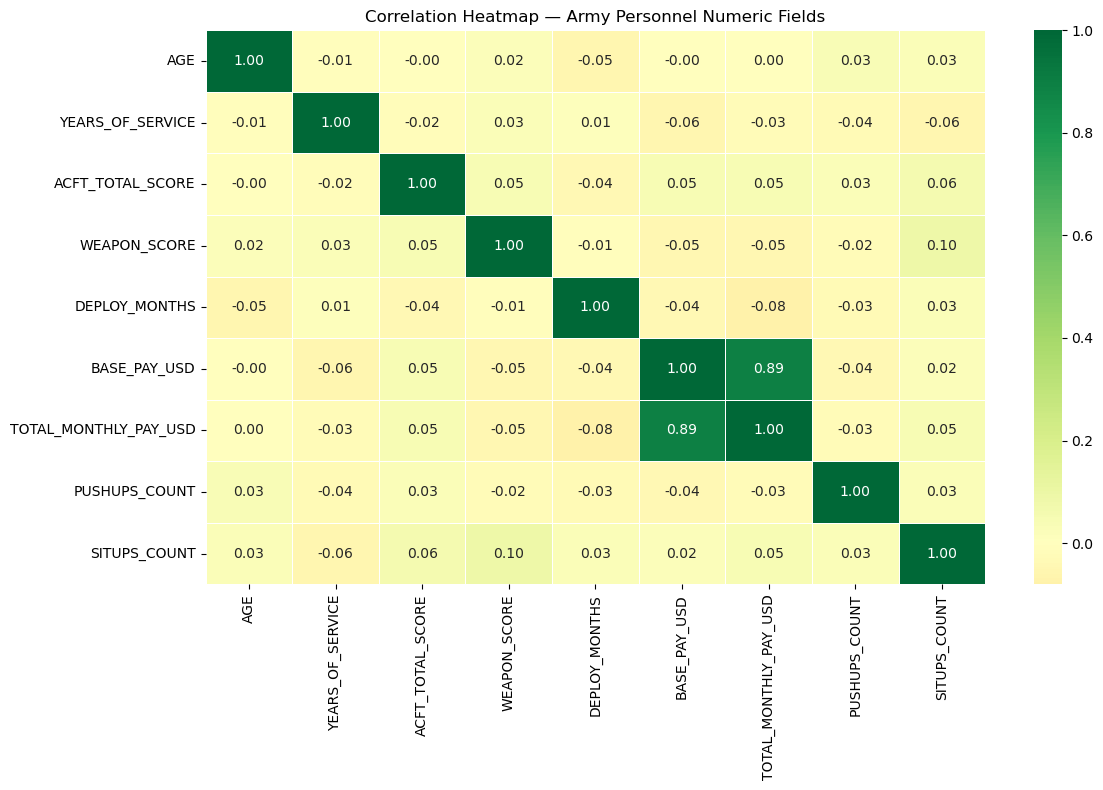

In [16]:
numeric_cols = ['AGE','YEARS_OF_SERVICE','ACFT_TOTAL_SCORE',
                  'WEAPON_SCORE','DEPLOY_MONTHS','BASE_PAY_USD',
                  'TOTAL_MONTHLY_PAY_USD','PUSHUPS_COUNT','SITUPS_COUNT']

corr = df[numeric_cols].corr()
plt.figure(figsize=(12,8))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='RdYlGn',
            linewidths=0.5, center=0)
plt.title('Correlation Heatmap — Army Personnel Numeric Fields')
plt.tight_layout(); plt.savefig('heatmap.png', dpi=150); plt.show()

## Full EDA Summary Table

In [17]:
summary = pd.DataFrame({
    'dtype':      df.dtypes,
    'nulls':      df.isnull().sum(),
    'null_pct':   (df.isnull().sum()/len(df)*100).round(2),
    'unique':     df.nunique(),
    'top_value':  [df[c].mode()[0] if df[c].nunique()<50 else 'N/A' for c in df.columns]
})
print(summary.to_string())
summary.to_csv('eda_summary.csv', index=True)

                          dtype  nulls  null_pct  unique                   top_value
SOLDIER_ID               object      0       0.0     500                         N/A
LAST_NAME                object      0       0.0      22                       Davis
FIRST_NAME               object      0       0.0      30                       James
GENDER                   object      0       0.0       2                           M
AGE                       int64      0       0.0      28                          21
HOME_STATE               object      0       0.0      20                          CO
RANK                     object      0       0.0      16                         CPT
PAY_GRADE                object      0       0.0      15                          E8
MOS_CODE                 object      0       0.0      15                         42A
MOS_TITLE                object      0       0.0      15  Human Resources Specialist
MOS_BRANCH               object      0       0.0      10         

## Export clean data

In [18]:
# Save the cleaned, enriched dataframe
df.to_csv('army_personnel_clean.csv', index=False)
df.to_excel('army_personnel_clean.xlsx', index=False)
print(f'Exported {len(df)} rows, {len(df.columns)} columns')

Exported 500 rows, 53 columns
